# Define constants

In [ ]:
CLEAN_FEATURES_PATH = "../../features/opus-clean.npz"
NOISY_FEATURES_PATH = "../../features/opus-noisy.npz"
MODEL_SAVE_PATH = "../../svm-models/opus"
RANDOM_STATE = 42

SVM_KERNEL = 'rbf'
SVM_GAMMA = 'scale'
SVM_C = 10
SVM_TEST_SIZE = 0.1
SVM_CV_FOLDS = 5
SVM_RANDOM_STATE = RANDOM_STATE

SVM_KFOLD_N_SPLITS = SVM_CV_FOLDS
SVM_KFOLD_RANDOM_STATE = SVM_RANDOM_STATE
SVM_KFOLD_TEST_SIZE = SVM_TEST_SIZE
SVM_KFOLD_KERNEL = SVM_KERNEL
SVM_KFOLD_C = SVM_C
SVM_KFOLD_GAMMA = SVM_GAMMA

SVM_SKFOLD_N_SPLITS = SVM_CV_FOLDS
SVM_SKFOLD_RANDOM_STATE = SVM_RANDOM_STATE
SVM_SKFOLD_TEST_SIZE = SVM_TEST_SIZE
SVM_SKFOLD_KERNEL = SVM_KERNEL
SVM_SKFOLD_C = SVM_C
SVM_SKFOLD_GAMMA = SVM_GAMMA

import os
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
SVM_MODEL_PATH = os.path.join(MODEL_SAVE_PATH, 'model.pkl')
SVM_SCALER_PATH = os.path.join(MODEL_SAVE_PATH, 'scaler.pkl')
SVM_ENCODER_PATH = os.path.join(MODEL_SAVE_PATH, 'label_encoder.pkl')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
import random
import numpy as np
import tensorflow as tf

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Training

## Load features

In [2]:
data = np.load(CLEAN_FEATURES_PATH)
features = data['features']
labels = data['labels']

## Split data

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Flatten 2D CQT features to 1D for SVM input
features_flat = features.reshape(features.shape[0], -1)

# Encode labels
svm_label_encoder = LabelEncoder()
svm_encoded_labels = svm_label_encoder.fit_transform(labels)

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_flat)

# Train/test split
X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(
    features_scaled,
    svm_encoded_labels,
    test_size=SVM_TEST_SIZE,
    random_state=SVM_RANDOM_STATE,
    stratify=svm_encoded_labels
)

print(f"X_svm_train shape: {X_svm_train.shape}")
print(f"X_svm_test shape:  {X_svm_test.shape}")
print(f"Number of classes: {len(svm_label_encoder.classes_)}")

X_svm_train shape: (6480, 7200)
X_svm_test shape:  (720, 7200)
Number of classes: 36


## Train model

In [4]:
from sklearn.svm import SVC

svm_model = SVC(kernel=SVM_KERNEL, C=SVM_C, gamma=SVM_GAMMA, random_state=SVM_RANDOM_STATE)

print("Training SVM model...")
svm_model.fit(X_svm_train, y_svm_train)
print("Training complete.")

Training SVM model...
Training complete.


## Evaluate model

In [5]:
from sklearn.metrics import accuracy_score, classification_report

y_svm_pred = svm_model.predict(X_svm_test)

svm_accuracy = accuracy_score(y_svm_test, y_svm_pred)
print(f"Test Accuracy: {svm_accuracy:.4f}")

svm_class_labels = svm_label_encoder.classes_
report = classification_report(y_svm_test, y_svm_pred, target_names=svm_class_labels)
print("\nClassification Report:\n", report)

Test Accuracy: 0.9986

Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      1.00      1.00        20
     A#_major_4       1.00      1.00      1.00        20
     A#_minor_4       1.00      1.00      1.00        20
 A_diminished_4       1.00      1.00      1.00        20
      A_major_4       1.00      1.00      1.00        20
      A_minor_4       1.00      1.00      1.00        20
 B_diminished_4       1.00      1.00      1.00        20
      B_major_4       1.00      1.00      1.00        20
      B_minor_4       1.00      1.00      1.00        20
C#_diminished_4       1.00      1.00      1.00        20
     C#_major_4       1.00      1.00      1.00        20
     C#_minor_4       1.00      1.00      1.00        20
 C_diminished_4       1.00      1.00      1.00        20
      C_major_4       1.00      1.00      1.00        20
      C_minor_4       1.00      1.00      1.00        20
D#_diminished_4       1.00      1.00    

## Confusion Matrix

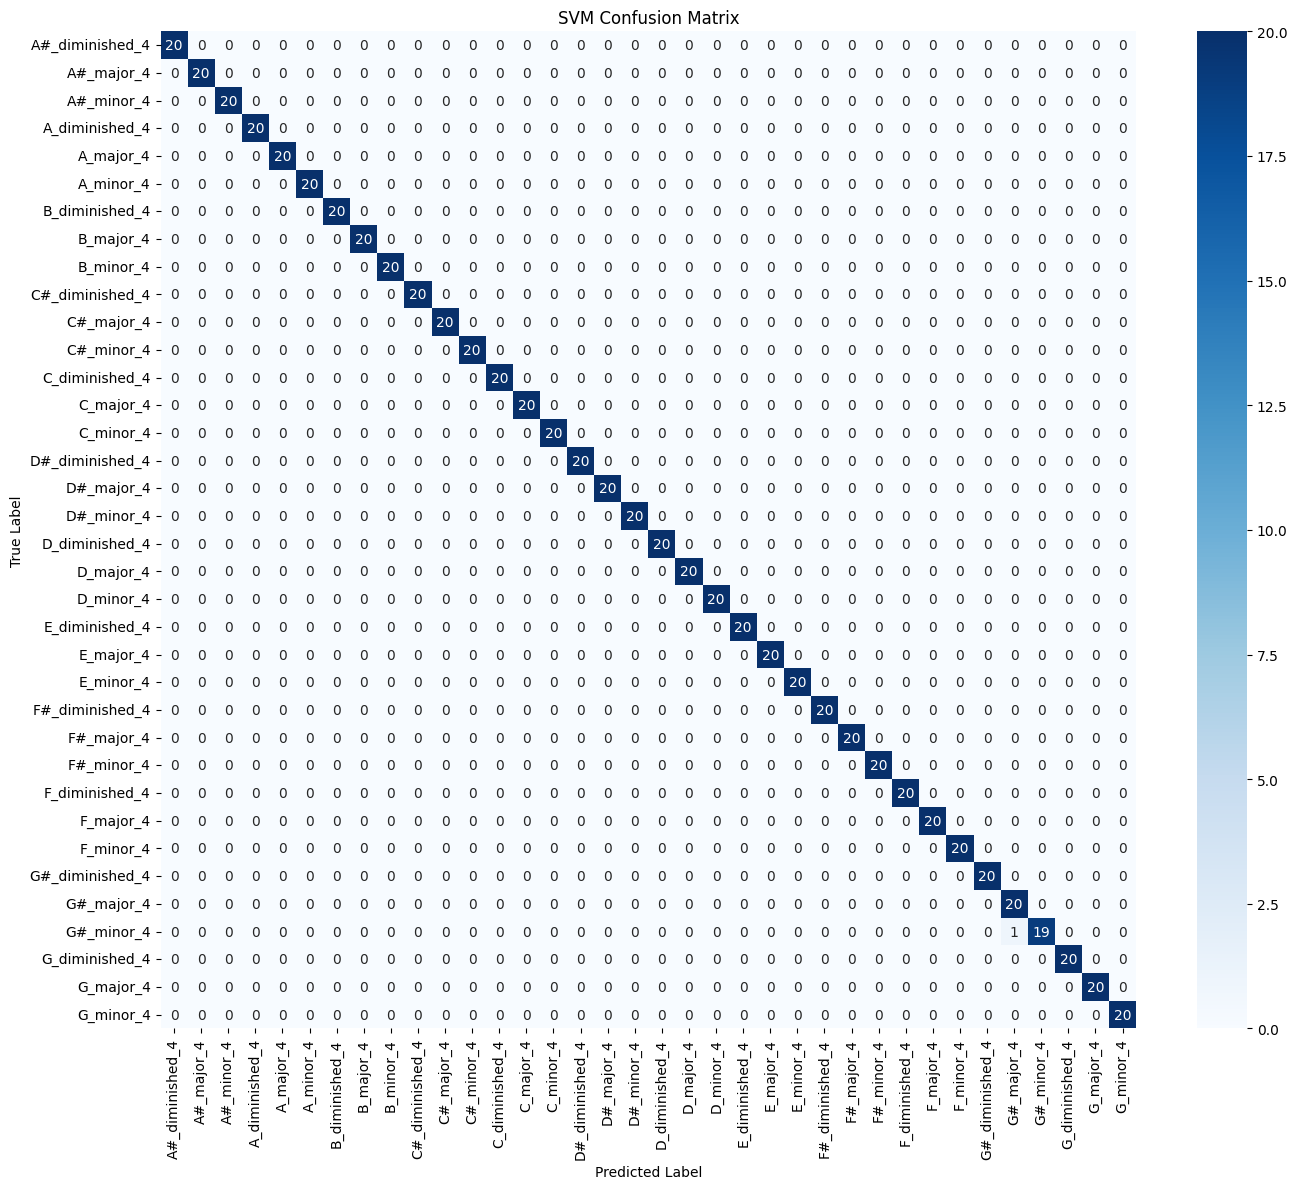

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_svm_test, y_svm_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_class_labels, yticklabels=svm_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix')
plt.tight_layout()
plt.show()

## Save SVM Model

In [7]:
import joblib

joblib.dump(svm_model, SVM_MODEL_PATH)
joblib.dump(scaler, SVM_SCALER_PATH)
joblib.dump(svm_label_encoder, SVM_ENCODER_PATH)

print(f"SVM model saved to {MODEL_SAVE_PATH}")

SVM model saved to ../../svm-models/opus


# K-Fold cross-validation

## Define constants

In [8]:
import numpy as np
from sklearn.metrics import accuracy_score, hinge_loss
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

## Train with K-Fold

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

svm_kf = KFold(
    n_splits=SVM_KFOLD_N_SPLITS,
    shuffle=True,
    random_state=SVM_KFOLD_RANDOM_STATE
)

svm_fold_train_accuracies = []
svm_fold_val_accuracies = []
svm_fold_test_accuracies = []

svm_fold_train_losses = []
svm_fold_val_losses = []
svm_fold_test_losses = []

svm_fold_confusion_matrices = []

svm_all_class_ids = np.arange(len(svm_label_encoder.classes_))

for fold, (train_val_index, test_index) in enumerate(svm_kf.split(features_flat, svm_encoded_labels)):
    print(f"\n--- Fold {fold+1}/{svm_kf.n_splits} ---")

    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SVM_KFOLD_TEST_SIZE,
        random_state=SVM_KFOLD_RANDOM_STATE,
        stratify=svm_encoded_labels[train_val_index]
    )

    X_train_fold_raw = features_flat[train_index]
    X_val_fold_raw   = features_flat[val_index]
    X_test_fold_raw  = features_flat[test_index]

    y_train_fold = svm_encoded_labels[train_index]
    y_val_fold   = svm_encoded_labels[val_index]
    y_test_fold  = svm_encoded_labels[test_index]

    fold_scaler = StandardScaler()
    X_train_fold = fold_scaler.fit_transform(X_train_fold_raw)
    X_val_fold   = fold_scaler.transform(X_val_fold_raw)
    X_test_fold  = fold_scaler.transform(X_test_fold_raw)

    svm_fold_model = SVC(
        kernel=SVM_KFOLD_KERNEL,
        C=SVM_KFOLD_C,
        gamma=SVM_KFOLD_GAMMA,
        decision_function_shape='ovr',
        random_state=SVM_KFOLD_RANDOM_STATE
    )

    print(f"Training SVM for Fold {fold+1}...")
    svm_fold_model.fit(X_train_fold, y_train_fold)

    train_pred = svm_fold_model.predict(X_train_fold)
    val_pred   = svm_fold_model.predict(X_val_fold)
    test_pred  = svm_fold_model.predict(X_test_fold)

    train_scores = svm_fold_model.decision_function(X_train_fold)
    val_scores   = svm_fold_model.decision_function(X_val_fold)
    test_scores  = svm_fold_model.decision_function(X_test_fold)

    train_accuracy = accuracy_score(y_train_fold, train_pred)
    val_accuracy   = accuracy_score(y_val_fold, val_pred)
    test_accuracy  = accuracy_score(y_test_fold, test_pred)

    train_loss = hinge_loss(y_train_fold, train_scores, labels=svm_all_class_ids)
    val_loss   = hinge_loss(y_val_fold, val_scores, labels=svm_all_class_ids)
    test_loss  = hinge_loss(y_test_fold, test_scores, labels=svm_all_class_ids)

    svm_fold_train_accuracies.append(train_accuracy)
    svm_fold_val_accuracies.append(val_accuracy)
    svm_fold_test_accuracies.append(test_accuracy)

    svm_fold_train_losses.append(train_loss)
    svm_fold_val_losses.append(val_loss)
    svm_fold_test_losses.append(test_loss)

    svm_fold_confusion_matrices.append(confusion_matrix(y_test_fold, test_pred))

    print(
        f"Fold {fold+1} - Train Accuracy: {train_accuracy:.4f}, "
        f"Val Accuracy: {val_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}"
    )
    print(
        f"Fold {fold+1} - Train Hinge Loss: {train_loss:.4f}, "
        f"Val Hinge Loss: {val_loss:.4f}, Test Hinge Loss: {test_loss:.4f}"
    )

print("\nSVM K-Fold Cross-Validation complete.")


--- Fold 1/5 ---
Training SVM for Fold 1...
Fold 1 - Train Accuracy: 1.0000, Val Accuracy: 0.9965, Test Accuracy: 0.9979
Fold 1 - Train Hinge Loss: 0.0000, Val Hinge Loss: 0.0175, Test Hinge Loss: 0.0119

--- Fold 2/5 ---
Training SVM for Fold 2...
Fold 2 - Train Accuracy: 1.0000, Val Accuracy: 0.9965, Test Accuracy: 0.9972
Fold 2 - Train Hinge Loss: 0.0000, Val Hinge Loss: 0.0087, Test Hinge Loss: 0.0211

--- Fold 3/5 ---
Training SVM for Fold 3...
Fold 3 - Train Accuracy: 1.0000, Val Accuracy: 0.9983, Test Accuracy: 0.9979
Fold 3 - Train Hinge Loss: 0.0000, Val Hinge Loss: 0.0087, Test Hinge Loss: 0.0105

--- Fold 4/5 ---
Training SVM for Fold 4...
Fold 4 - Train Accuracy: 1.0000, Val Accuracy: 1.0000, Test Accuracy: 0.9986
Fold 4 - Train Hinge Loss: 0.0000, Val Hinge Loss: 0.0000, Test Hinge Loss: 0.0070

--- Fold 5/5 ---
Training SVM for Fold 5...
Fold 5 - Train Accuracy: 1.0000, Val Accuracy: 1.0000, Test Accuracy: 0.9993
Fold 5 - Train Hinge Loss: 0.0000, Val Hinge Loss: 0.0000,

## Show class distribution

In [10]:
from collections import Counter
from sklearn.model_selection import train_test_split
import numpy as np

print("=" * 65)
print("              Class Distribution per Fold")
print("=" * 65)

class_ids = np.arange(len(svm_label_encoder.classes_))
class_names = svm_label_encoder.classes_

for fold, (train_val_index, test_index) in enumerate(svm_kf.split(features_flat, svm_encoded_labels)):
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SVM_KFOLD_TEST_SIZE,
        random_state=SVM_KFOLD_RANDOM_STATE,
        stratify=svm_encoded_labels[train_val_index]
    )

    train_dist = Counter(svm_encoded_labels[train_index])
    val_dist   = Counter(svm_encoded_labels[val_index])
    test_dist  = Counter(svm_encoded_labels[test_index])

    print(f"\n  Fold {fold+1}")
    print(f"  {'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}  {'Total':>8}")
    print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8}  {'-'*8}")

    for cls, name in zip(class_ids, class_names):
        tr = train_dist.get(cls, 0)
        vl = val_dist.get(cls, 0)
        te = test_dist.get(cls, 0)
        print(f"  {str(name):<20} {tr:>8} {vl:>8} {te:>8}  {tr+vl+te:>8}")

    print(
        f"  {'TOTAL':<20} {sum(train_dist.values()):>8} {sum(val_dist.values()):>8} "
        f"{sum(test_dist.values()):>8}  {sum(train_dist.values()) + sum(val_dist.values()) + sum(test_dist.values()):>8}"
    )

print("\n" + "=" * 65)

              Class Distribution per Fold

  Fold 1
  Class                   Train      Val     Test     Total
  -------------------- -------- -------- --------  --------
  A#_diminished_4           142       16       42       200
  A#_major_4                141       16       43       200
  A#_minor_4                134       15       51       200
  A_diminished_4            149       16       35       200
  A_major_4                 156       17       27       200
  A_minor_4                 134       15       51       200
  B_diminished_4            149       16       35       200
  B_major_4                 134       15       51       200
  B_minor_4                 140       15       45       200
  C#_diminished_4           149       17       34       200
  C#_major_4                150       17       33       200
  C#_minor_4                144       16       40       200
  C_diminished_4            141       16       43       200
  C_major_4                 146       16       3

## Confusion Matrix per Fold

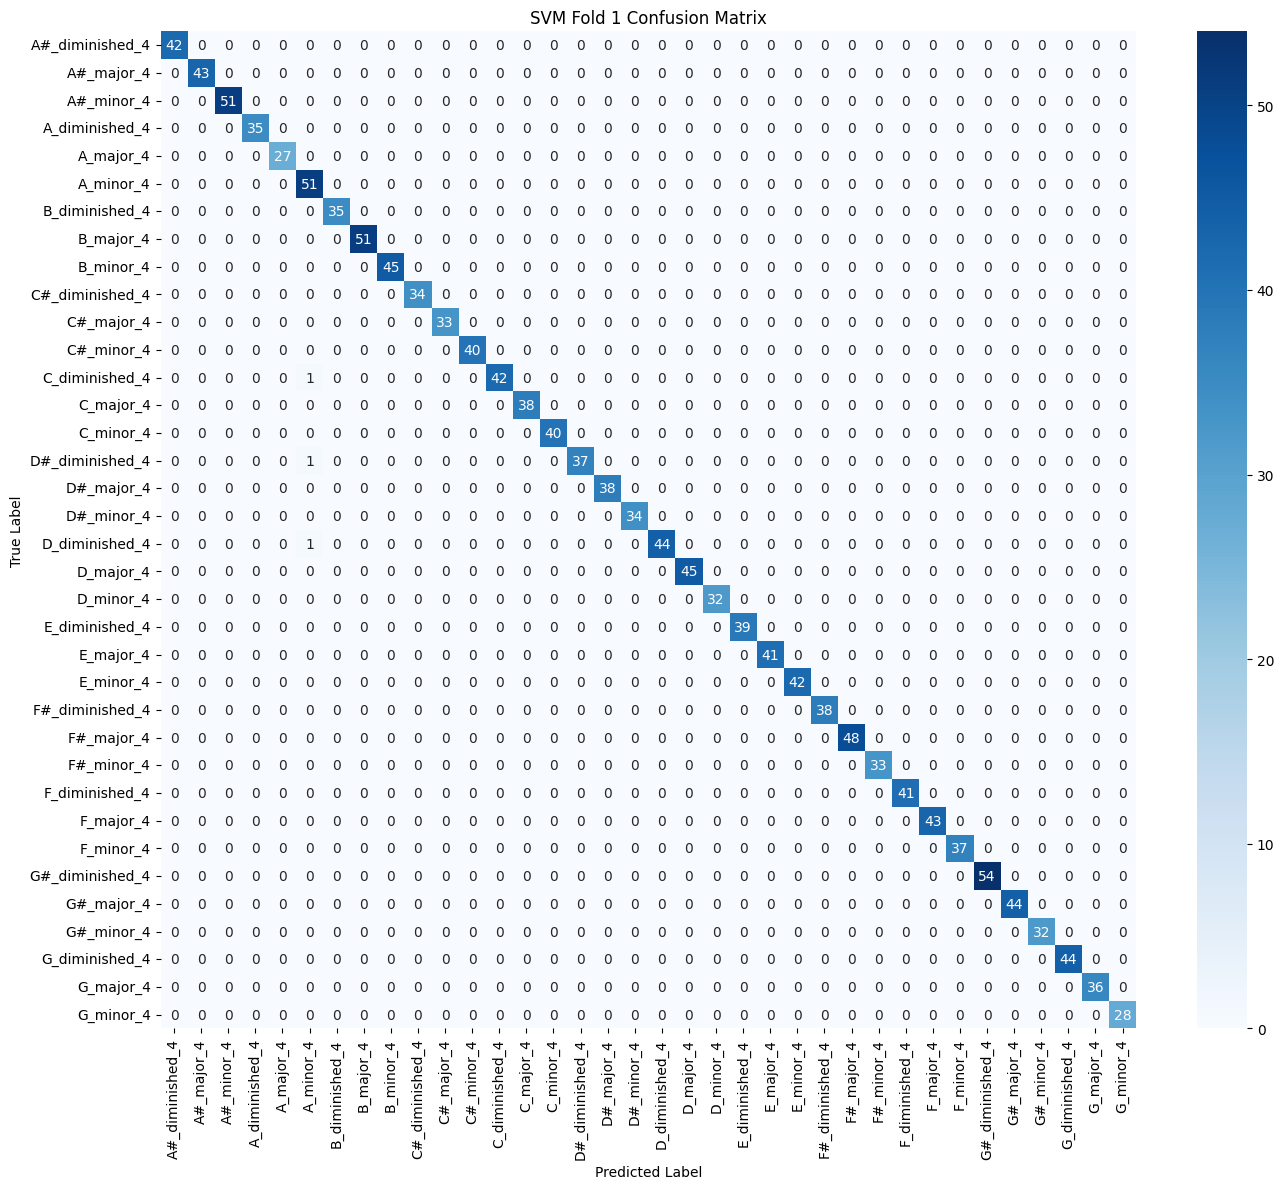

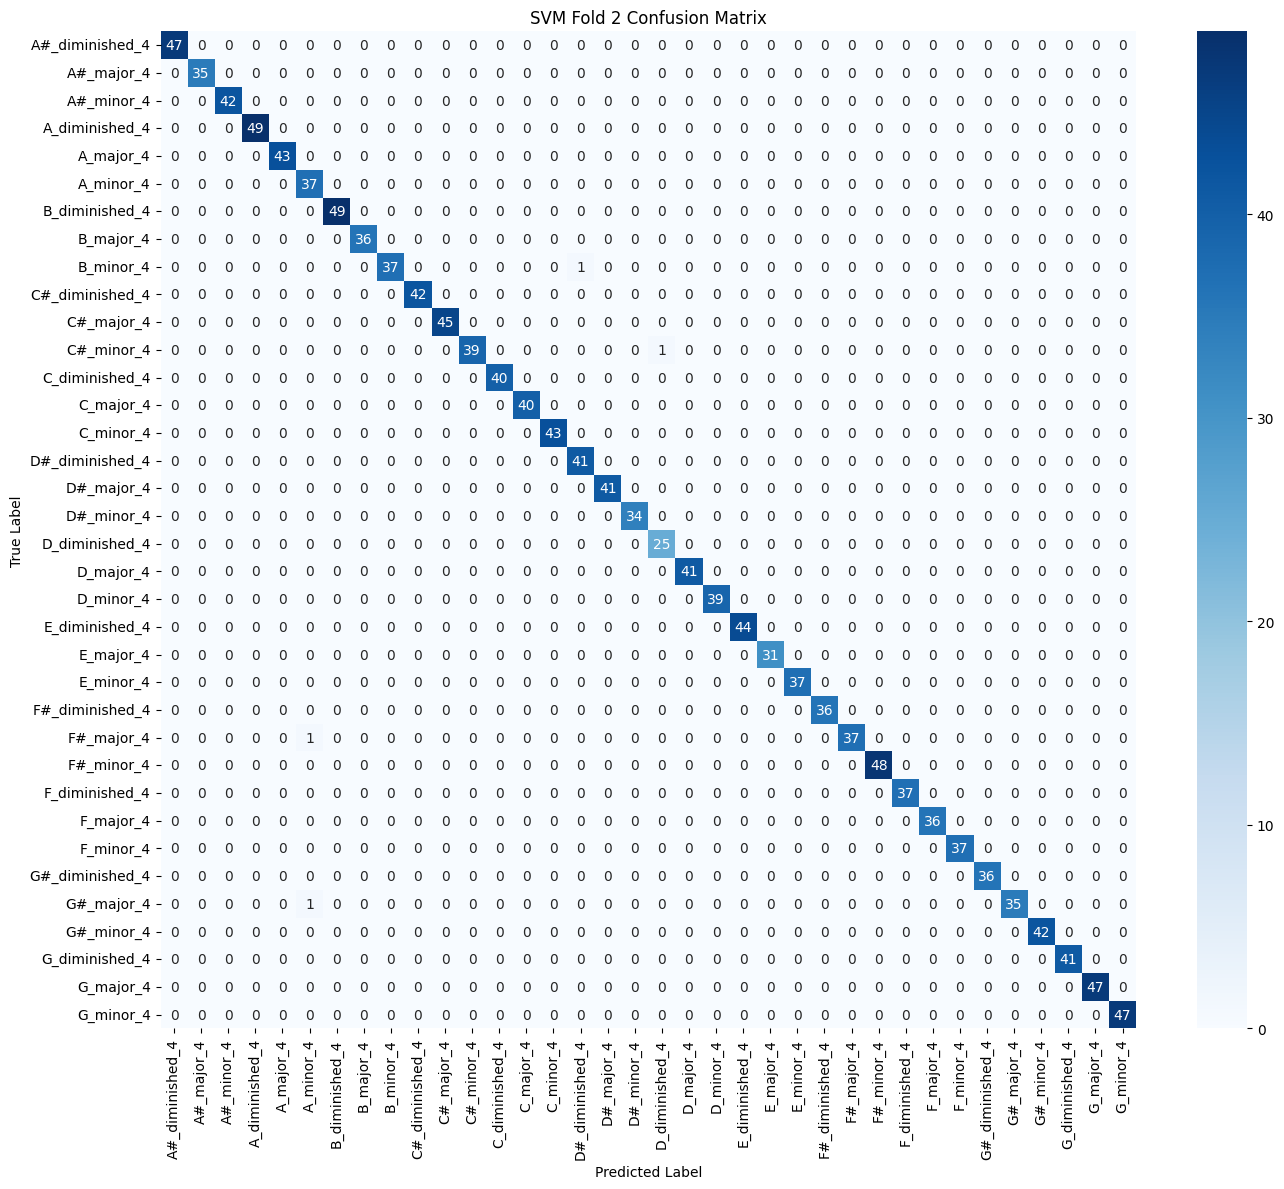

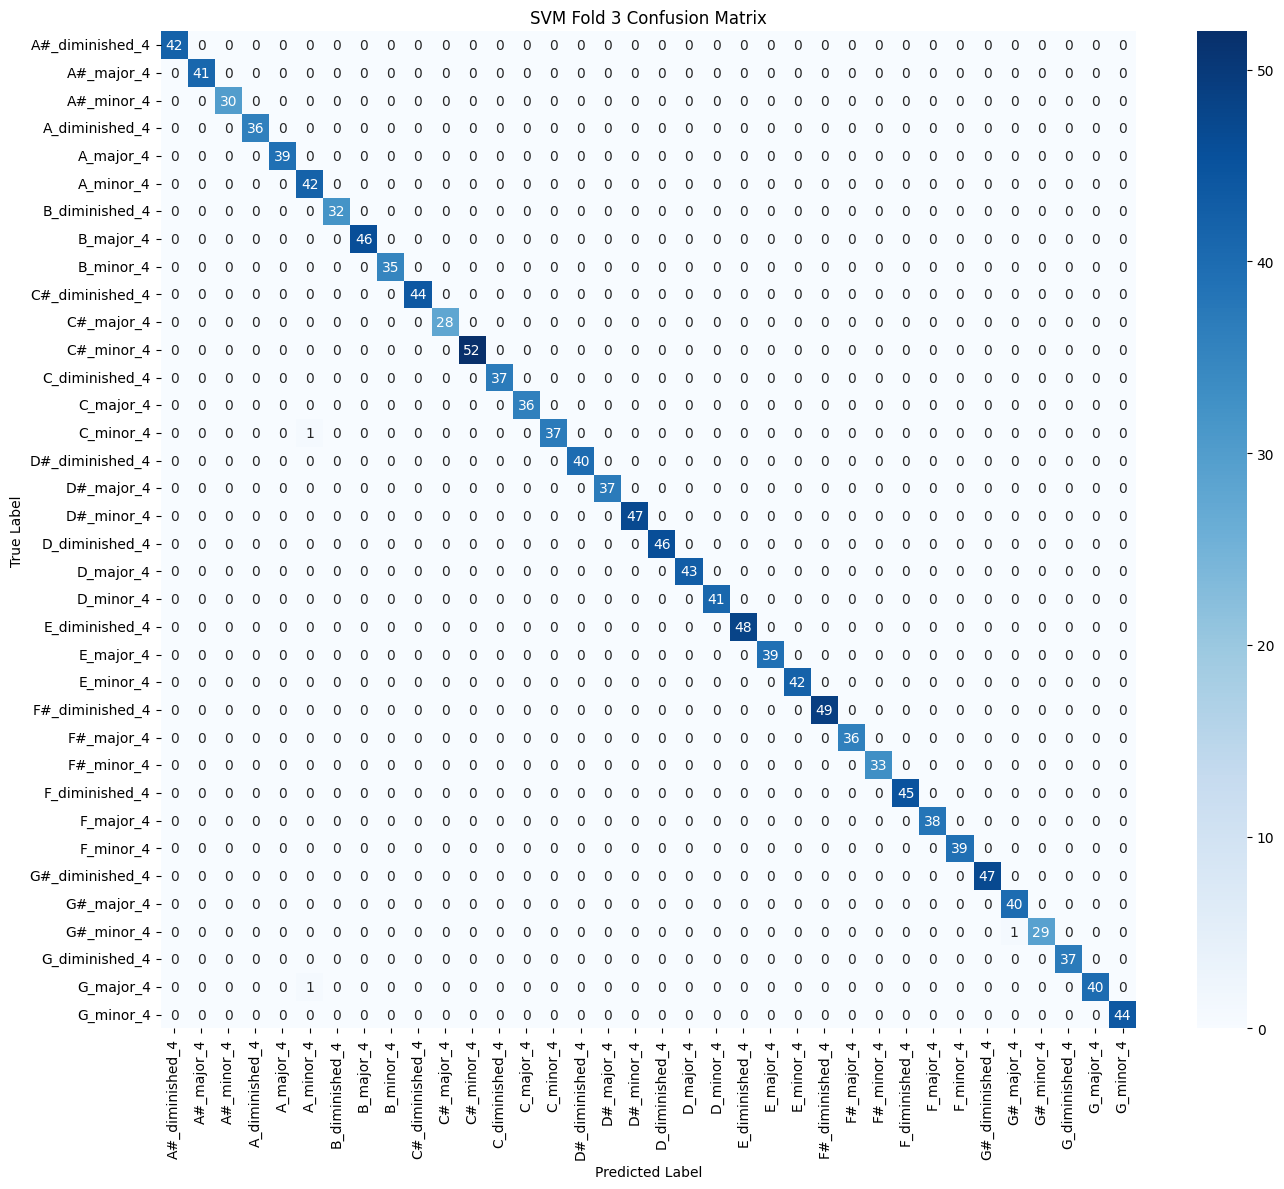

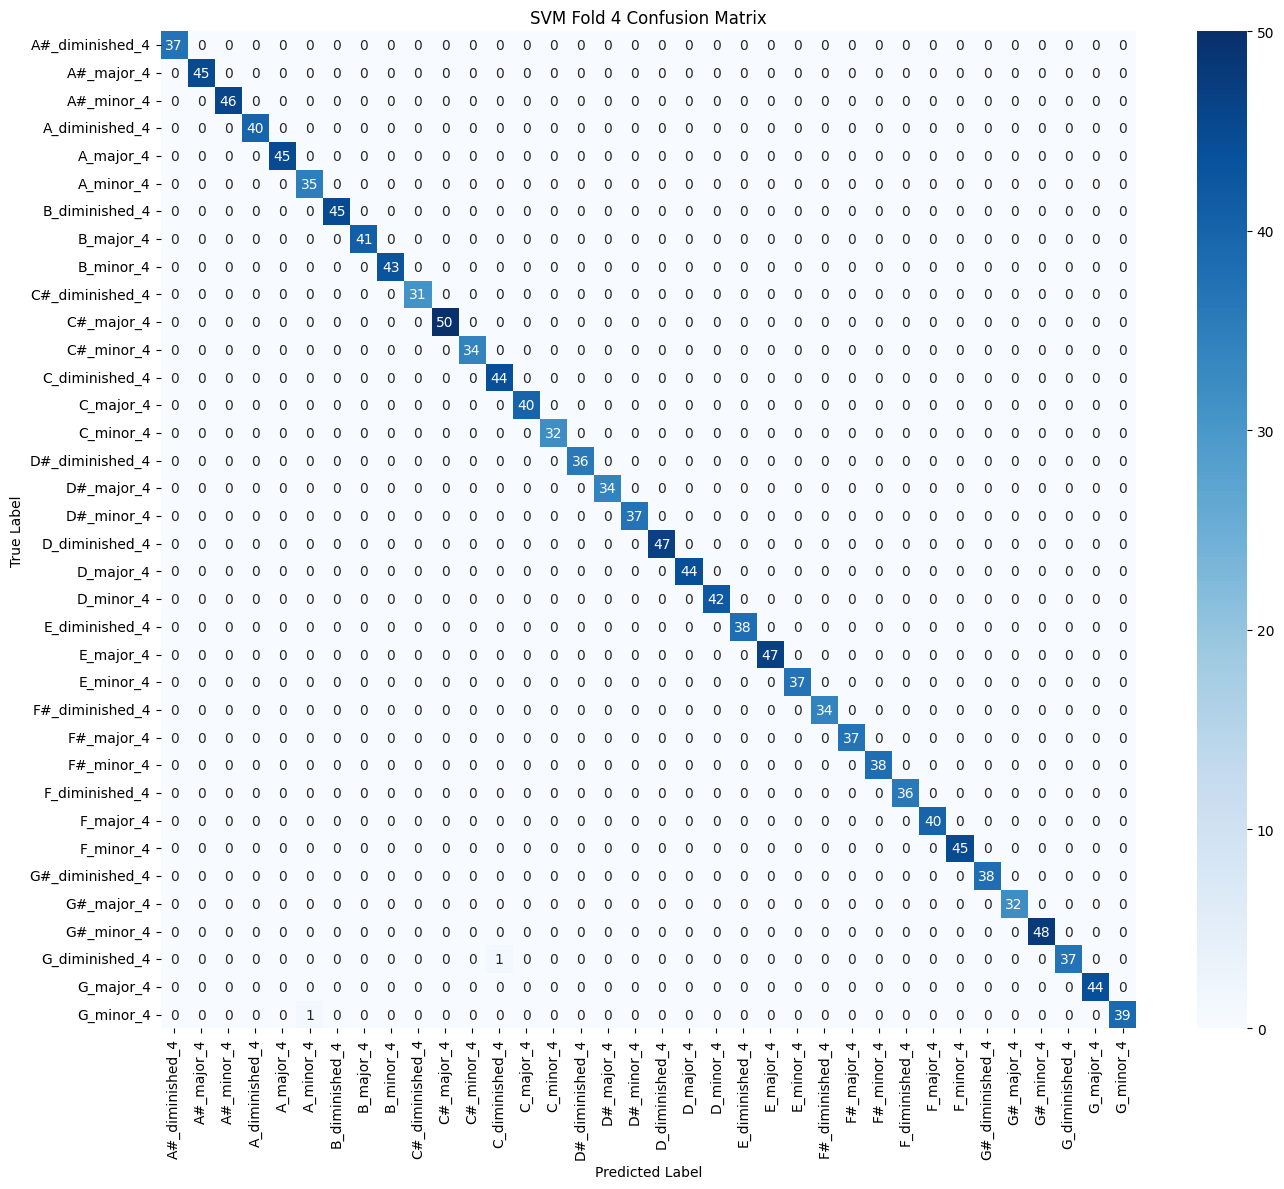

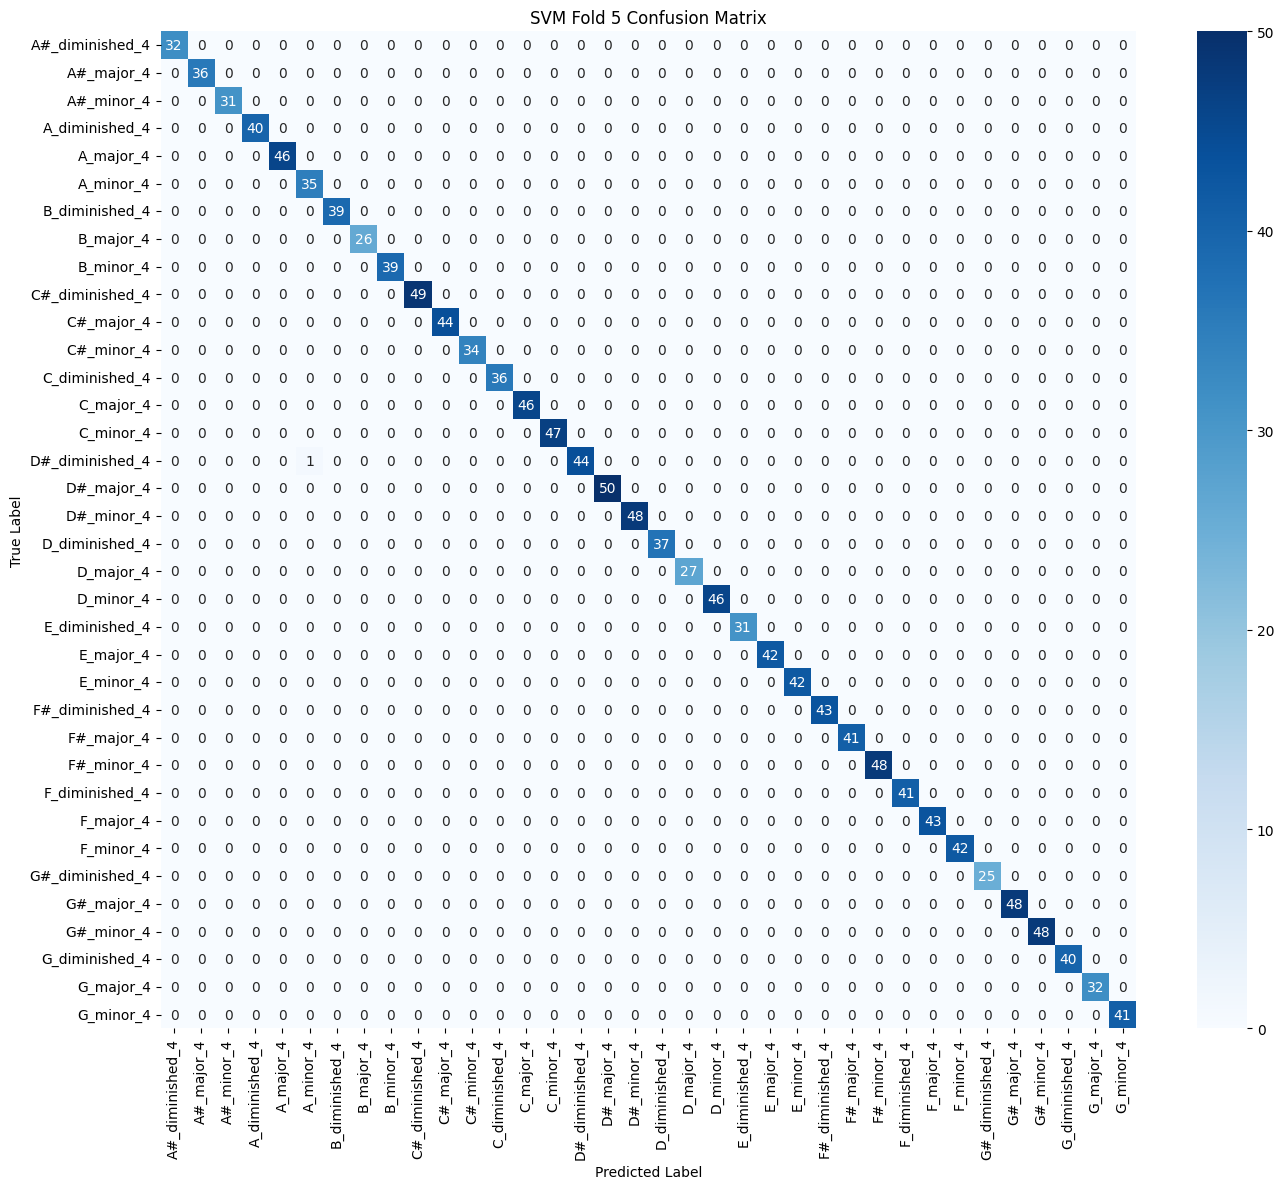

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

svm_class_labels = svm_label_encoder.classes_

for i, cm in enumerate(svm_fold_confusion_matrices):
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=svm_class_labels,
        yticklabels=svm_class_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'SVM Fold {i+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()

## Accuracy & Loss Plot

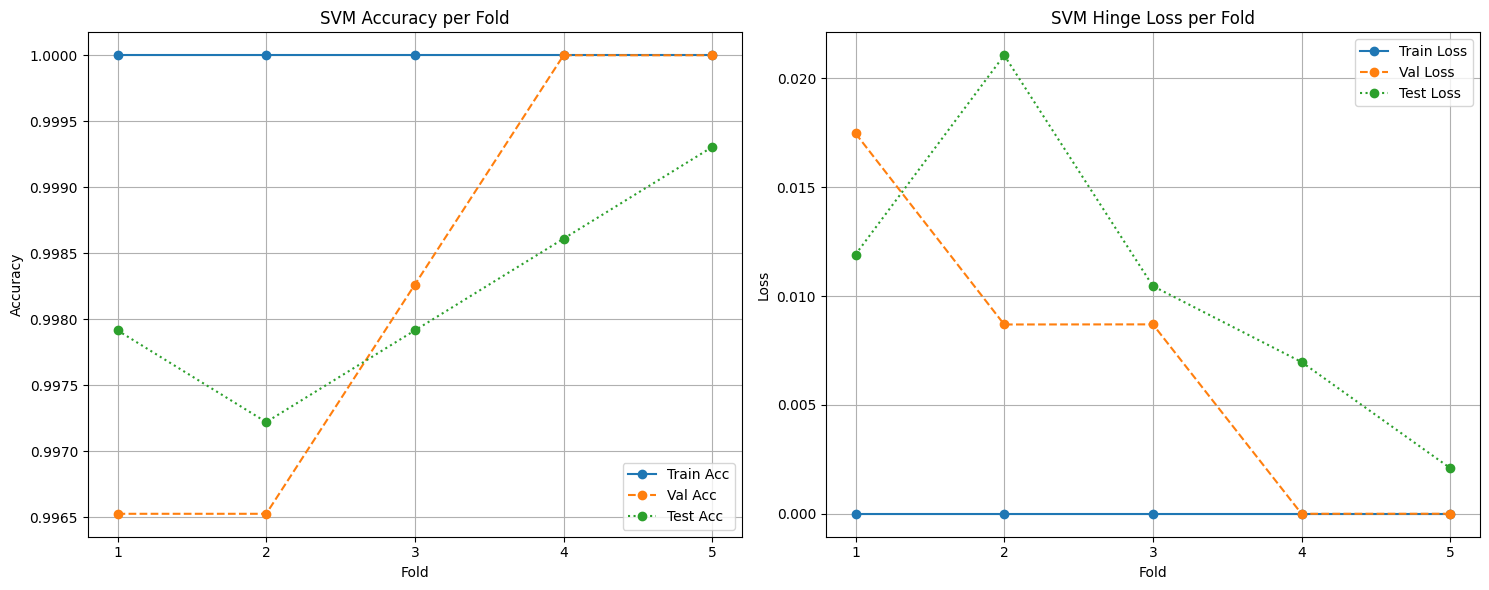

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fold_numbers = np.arange(1, len(svm_fold_train_accuracies) + 1)

plt.figure(figsize=(15, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(fold_numbers, svm_fold_train_accuracies, marker='o', label='Train Acc')
plt.plot(fold_numbers, svm_fold_val_accuracies, marker='o', linestyle='--', label='Val Acc')
plt.plot(fold_numbers, svm_fold_test_accuracies, marker='o', linestyle=':', label='Test Acc')
plt.title('SVM Accuracy per Fold')
plt.ylabel('Accuracy')
plt.xlabel('Fold')
plt.xticks(fold_numbers)
plt.legend(loc='lower right')
plt.grid(True)

# --- Loss (multiclass hinge loss) ---
plt.subplot(1, 2, 2)
plt.plot(fold_numbers, svm_fold_train_losses, marker='o', label='Train Loss')
plt.plot(fold_numbers, svm_fold_val_losses, marker='o', linestyle='--', label='Val Loss')
plt.plot(fold_numbers, svm_fold_test_losses, marker='o', linestyle=':', label='Test Loss')
plt.title('SVM Hinge Loss per Fold')
plt.ylabel('Loss')
plt.xlabel('Fold')
plt.xticks(fold_numbers)
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

## Mean & Std Deviation

In [13]:
import numpy as np

print("=" * 89)
print("                    SVM K-Fold Cross-Validation Summary")
print("=" * 89)
print(f"  {'':>6}  {'Train Acc':>10}  {'Val Acc':>10}  {'Test Acc':>10}  {'Train Loss':>11}  {'Val Loss':>10}  {'Test Loss':>10}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")

for i in range(len(svm_fold_train_accuracies)):
    print(
        f"  Fold {i+1:>1}  "
        f"{svm_fold_train_accuracies[i]:>10.4f}  "
        f"{svm_fold_val_accuracies[i]:>10.4f}  "
        f"{svm_fold_test_accuracies[i]:>10.4f}  "
        f"{svm_fold_train_losses[i]:>11.4f}  "
        f"{svm_fold_val_losses[i]:>10.4f}  "
        f"{svm_fold_test_losses[i]:>10.4f}"
    )

print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
print(
    f"  {'Mean':>6}  "
    f"{np.mean(svm_fold_train_accuracies):>10.4f}  "
    f"{np.mean(svm_fold_val_accuracies):>10.4f}  "
    f"{np.mean(svm_fold_test_accuracies):>10.4f}  "
    f"{np.mean(svm_fold_train_losses):>11.4f}  "
    f"{np.mean(svm_fold_val_losses):>10.4f}  "
    f"{np.mean(svm_fold_test_losses):>10.4f}"
)
print(
    f"  {'Std':>6}  "
    f"{np.std(svm_fold_train_accuracies):>10.4f}  "
    f"{np.std(svm_fold_val_accuracies):>10.4f}  "
    f"{np.std(svm_fold_test_accuracies):>10.4f}  "
    f"{np.std(svm_fold_train_losses):>11.4f}  "
    f"{np.std(svm_fold_val_losses):>10.4f}  "
    f"{np.std(svm_fold_test_losses):>10.4f}"
)
print("=" * 89)

                    SVM K-Fold Cross-Validation Summary
           Train Acc     Val Acc    Test Acc   Train Loss    Val Loss   Test Loss
  ------  ----------  ----------  ----------  -----------  ----------  ----------
  Fold 1      1.0000      0.9965      0.9979       0.0000      0.0175      0.0119
  Fold 2      1.0000      0.9965      0.9972       0.0000      0.0087      0.0211
  Fold 3      1.0000      0.9983      0.9979       0.0000      0.0087      0.0105
  Fold 4      1.0000      1.0000      0.9986       0.0000      0.0000      0.0070
  Fold 5      1.0000      1.0000      0.9993       0.0000      0.0000      0.0021
  ------  ----------  ----------  ----------  -----------  ----------  ----------
    Mean      1.0000      0.9983      0.9982       0.0000      0.0070      0.0105
     Std      0.0000      0.0016      0.0007       0.0000      0.0065      0.0063


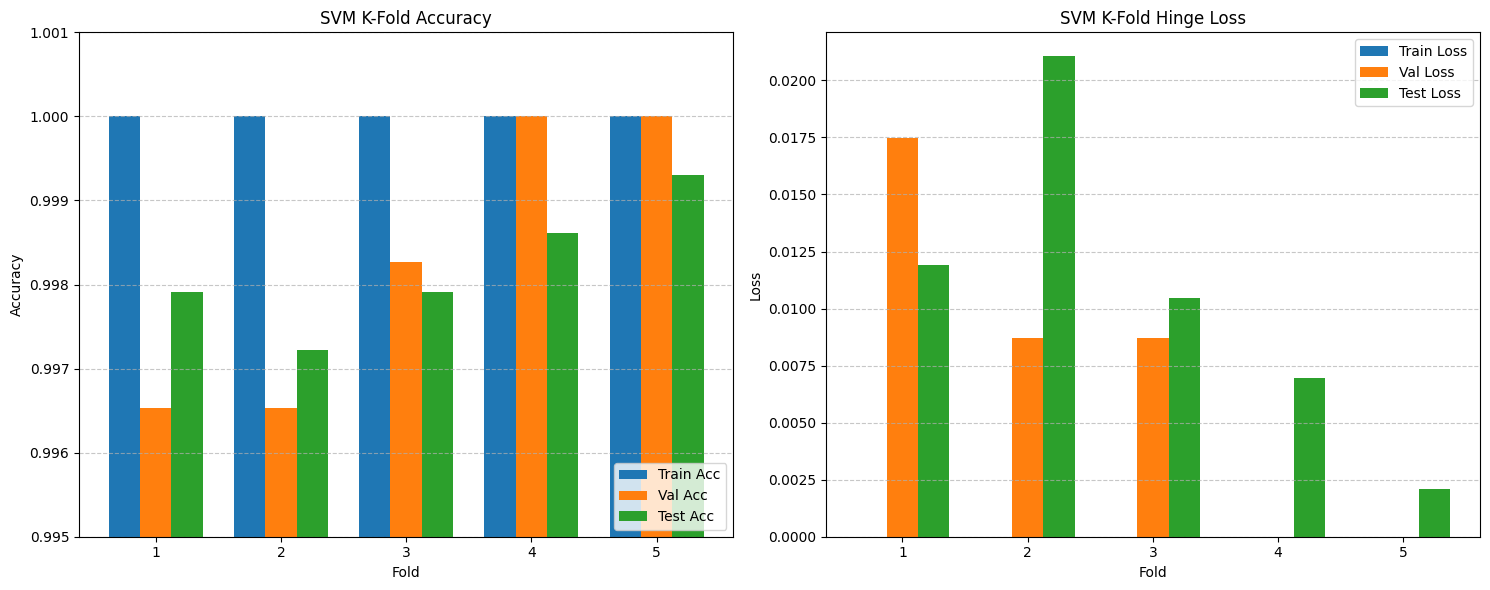

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming your data lists are already defined
fold_numbers = np.arange(1, len(svm_fold_train_accuracies) + 1)
width = 0.25  # The width of the bars

plt.figure(figsize=(15, 6))

# --- Accuracy Chart ---
plt.subplot(1, 2, 1)
plt.bar(fold_numbers - width, svm_fold_train_accuracies, width, label='Train Acc', color='#1f77b4')
plt.bar(fold_numbers, svm_fold_val_accuracies, width, label='Val Acc', color='#ff7f0e')
plt.bar(fold_numbers + width, svm_fold_test_accuracies, width, label='Test Acc', color='#2ca02c')

plt.title('SVM K-Fold Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Fold')
plt.xticks(fold_numbers)
plt.ylim(0.995, 1.001) # Zooming in like your original plot
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# --- Loss Chart ---
plt.subplot(1, 2, 2)
plt.bar(fold_numbers - width, svm_fold_train_losses, width, label='Train Loss', color='#1f77b4')
plt.bar(fold_numbers, svm_fold_val_losses, width, label='Val Loss', color='#ff7f0e')
plt.bar(fold_numbers + width, svm_fold_test_losses, width, label='Test Loss', color='#2ca02c')

plt.title('SVM K-Fold Hinge Loss')
plt.ylabel('Loss')
plt.xlabel('Fold')
plt.xticks(fold_numbers)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Stratified K-Fold

## Define constants

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, hinge_loss
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

## Train with Stratified K-Fold

In [15]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

svm_skf = StratifiedKFold(
    n_splits=SVM_SKFOLD_N_SPLITS,
    shuffle=True,
    random_state=SVM_SKFOLD_RANDOM_STATE
)

svm_sfold_train_accuracies = []
svm_sfold_val_accuracies = []
svm_sfold_test_accuracies = []

svm_sfold_train_losses = []
svm_sfold_val_losses = []
svm_sfold_test_losses = []

svm_sfold_confusion_matrices = []

svm_all_class_ids = np.arange(len(svm_label_encoder.classes_))

for fold, (train_val_index, test_index) in enumerate(svm_skf.split(features_flat, svm_encoded_labels)):
    print(f"\n--- Fold {fold+1}/{svm_skf.n_splits} ---")

    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SVM_SKFOLD_TEST_SIZE,
        random_state=SVM_SKFOLD_RANDOM_STATE,
        stratify=svm_encoded_labels[train_val_index]
    )

    X_train_fold_raw = features_flat[train_index]
    X_val_fold_raw   = features_flat[val_index]
    X_test_fold_raw  = features_flat[test_index]

    y_train_fold = svm_encoded_labels[train_index]
    y_val_fold   = svm_encoded_labels[val_index]
    y_test_fold  = svm_encoded_labels[test_index]

    fold_scaler = StandardScaler()
    X_train_fold = fold_scaler.fit_transform(X_train_fold_raw)
    X_val_fold   = fold_scaler.transform(X_val_fold_raw)
    X_test_fold  = fold_scaler.transform(X_test_fold_raw)

    svm_fold_model = SVC(
        kernel=SVM_SKFOLD_KERNEL,
        C=SVM_SKFOLD_C,
        gamma=SVM_SKFOLD_GAMMA,
        decision_function_shape='ovr',
        random_state=SVM_SKFOLD_RANDOM_STATE
    )

    print(f"Training SVM for Fold {fold+1}...")
    svm_fold_model.fit(X_train_fold, y_train_fold)

    train_pred = svm_fold_model.predict(X_train_fold)
    val_pred   = svm_fold_model.predict(X_val_fold)
    test_pred  = svm_fold_model.predict(X_test_fold)

    train_scores = svm_fold_model.decision_function(X_train_fold)
    val_scores   = svm_fold_model.decision_function(X_val_fold)
    test_scores  = svm_fold_model.decision_function(X_test_fold)

    train_accuracy = accuracy_score(y_train_fold, train_pred)
    val_accuracy   = accuracy_score(y_val_fold, val_pred)
    test_accuracy  = accuracy_score(y_test_fold, test_pred)

    train_loss = hinge_loss(y_train_fold, train_scores, labels=svm_all_class_ids)
    val_loss   = hinge_loss(y_val_fold, val_scores, labels=svm_all_class_ids)
    test_loss  = hinge_loss(y_test_fold, test_scores, labels=svm_all_class_ids)

    svm_sfold_train_accuracies.append(train_accuracy)
    svm_sfold_val_accuracies.append(val_accuracy)
    svm_sfold_test_accuracies.append(test_accuracy)

    svm_sfold_train_losses.append(train_loss)
    svm_sfold_val_losses.append(val_loss)
    svm_sfold_test_losses.append(test_loss)

    svm_sfold_confusion_matrices.append(confusion_matrix(y_test_fold, test_pred))

    print(
        f"Fold {fold+1} - Train Accuracy: {train_accuracy:.4f}, "
        f"Val Accuracy: {val_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}"
    )
    print(
        f"Fold {fold+1} - Train Hinge Loss: {train_loss:.4f}, "
        f"Val Hinge Loss: {val_loss:.4f}, Test Hinge Loss: {test_loss:.4f}"
    )

print("\nSVM Stratified K-Fold Cross-Validation complete.")


--- Fold 1/5 ---
Training SVM for Fold 1...
Fold 1 - Train Accuracy: 1.0000, Val Accuracy: 0.9983, Test Accuracy: 0.9958
Fold 1 - Train Hinge Loss: 0.0000, Val Hinge Loss: 0.0035, Test Hinge Loss: 0.0266

--- Fold 2/5 ---
Training SVM for Fold 2...
Fold 2 - Train Accuracy: 1.0000, Val Accuracy: 1.0000, Test Accuracy: 0.9979
Fold 2 - Train Hinge Loss: 0.0000, Val Hinge Loss: 0.0000, Test Hinge Loss: 0.0098

--- Fold 3/5 ---
Training SVM for Fold 3...
Fold 3 - Train Accuracy: 1.0000, Val Accuracy: 1.0000, Test Accuracy: 1.0000
Fold 3 - Train Hinge Loss: 0.0000, Val Hinge Loss: 0.0000, Test Hinge Loss: 0.0000

--- Fold 4/5 ---
Training SVM for Fold 4...
Fold 4 - Train Accuracy: 1.0000, Val Accuracy: 0.9983, Test Accuracy: 0.9986
Fold 4 - Train Hinge Loss: 0.0000, Val Hinge Loss: 0.0070, Test Hinge Loss: 0.0121

--- Fold 5/5 ---
Training SVM for Fold 5...
Fold 5 - Train Accuracy: 1.0000, Val Accuracy: 0.9965, Test Accuracy: 0.9979
Fold 5 - Train Hinge Loss: 0.0000, Val Hinge Loss: 0.0070,

## Show class distribution

In [16]:
from collections import Counter
from sklearn.model_selection import train_test_split
import numpy as np

print("=" * 65)
print("              Class Distribution per Fold")
print("=" * 65)

class_ids = np.arange(len(svm_label_encoder.classes_))
class_names = svm_label_encoder.classes_

for fold, (train_val_index, test_index) in enumerate(svm_skf.split(features_flat, svm_encoded_labels)):
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SVM_SKFOLD_TEST_SIZE,
        random_state=SVM_SKFOLD_RANDOM_STATE,
        stratify=svm_encoded_labels[train_val_index]
    )

    train_dist = Counter(svm_encoded_labels[train_index])
    val_dist   = Counter(svm_encoded_labels[val_index])
    test_dist  = Counter(svm_encoded_labels[test_index])

    print(f"\n  Fold {fold+1}")
    print(f"  {'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}  {'Total':>8}")
    print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8}  {'-'*8}")

    for cls, name in zip(class_ids, class_names):
        tr = train_dist.get(cls, 0)
        vl = val_dist.get(cls, 0)
        te = test_dist.get(cls, 0)
        print(f"  {str(name):<20} {tr:>8} {vl:>8} {te:>8}  {tr+vl+te:>8}")

    print(
        f"  {'TOTAL':<20} {sum(train_dist.values()):>8} {sum(val_dist.values()):>8} "
        f"{sum(test_dist.values()):>8}  {sum(train_dist.values()) + sum(val_dist.values()) + sum(test_dist.values()):>8}"
    )

print("\n" + "=" * 65)

              Class Distribution per Fold

  Fold 1
  Class                   Train      Val     Test     Total
  -------------------- -------- -------- --------  --------
  A#_diminished_4           144       16       40       200
  A#_major_4                144       16       40       200
  A#_minor_4                144       16       40       200
  A_diminished_4            144       16       40       200
  A_major_4                 144       16       40       200
  A_minor_4                 144       16       40       200
  B_diminished_4            144       16       40       200
  B_major_4                 144       16       40       200
  B_minor_4                 144       16       40       200
  C#_diminished_4           144       16       40       200
  C#_major_4                144       16       40       200
  C#_minor_4                144       16       40       200
  C_diminished_4            144       16       40       200
  C_major_4                 144       16       4

## Confusion Matrix per Fold

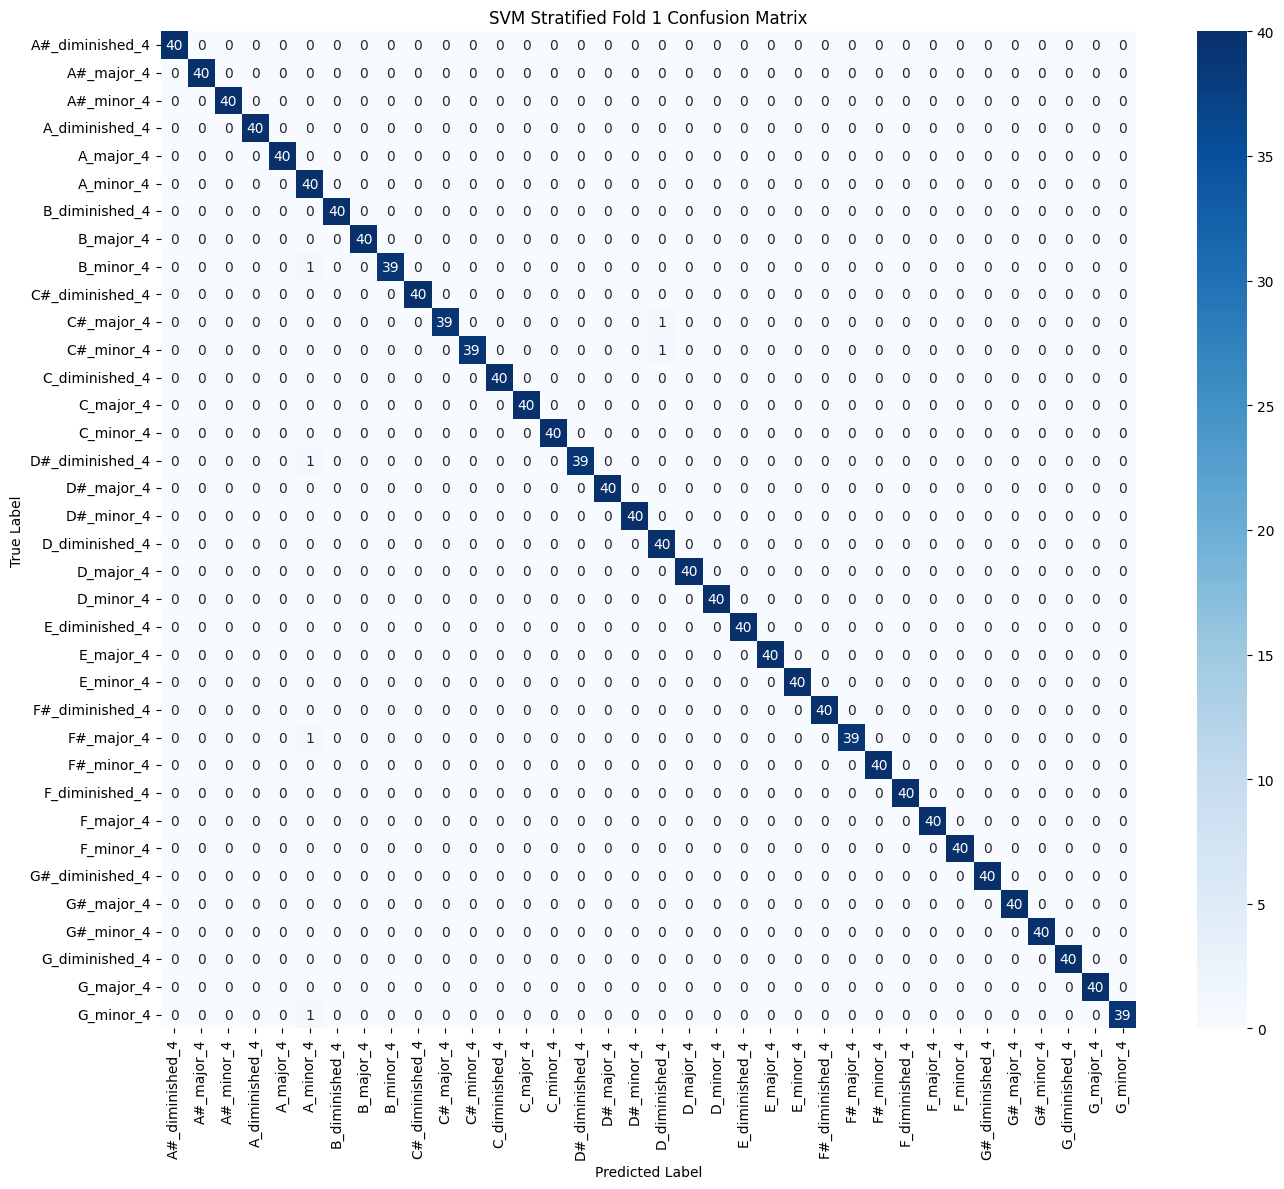

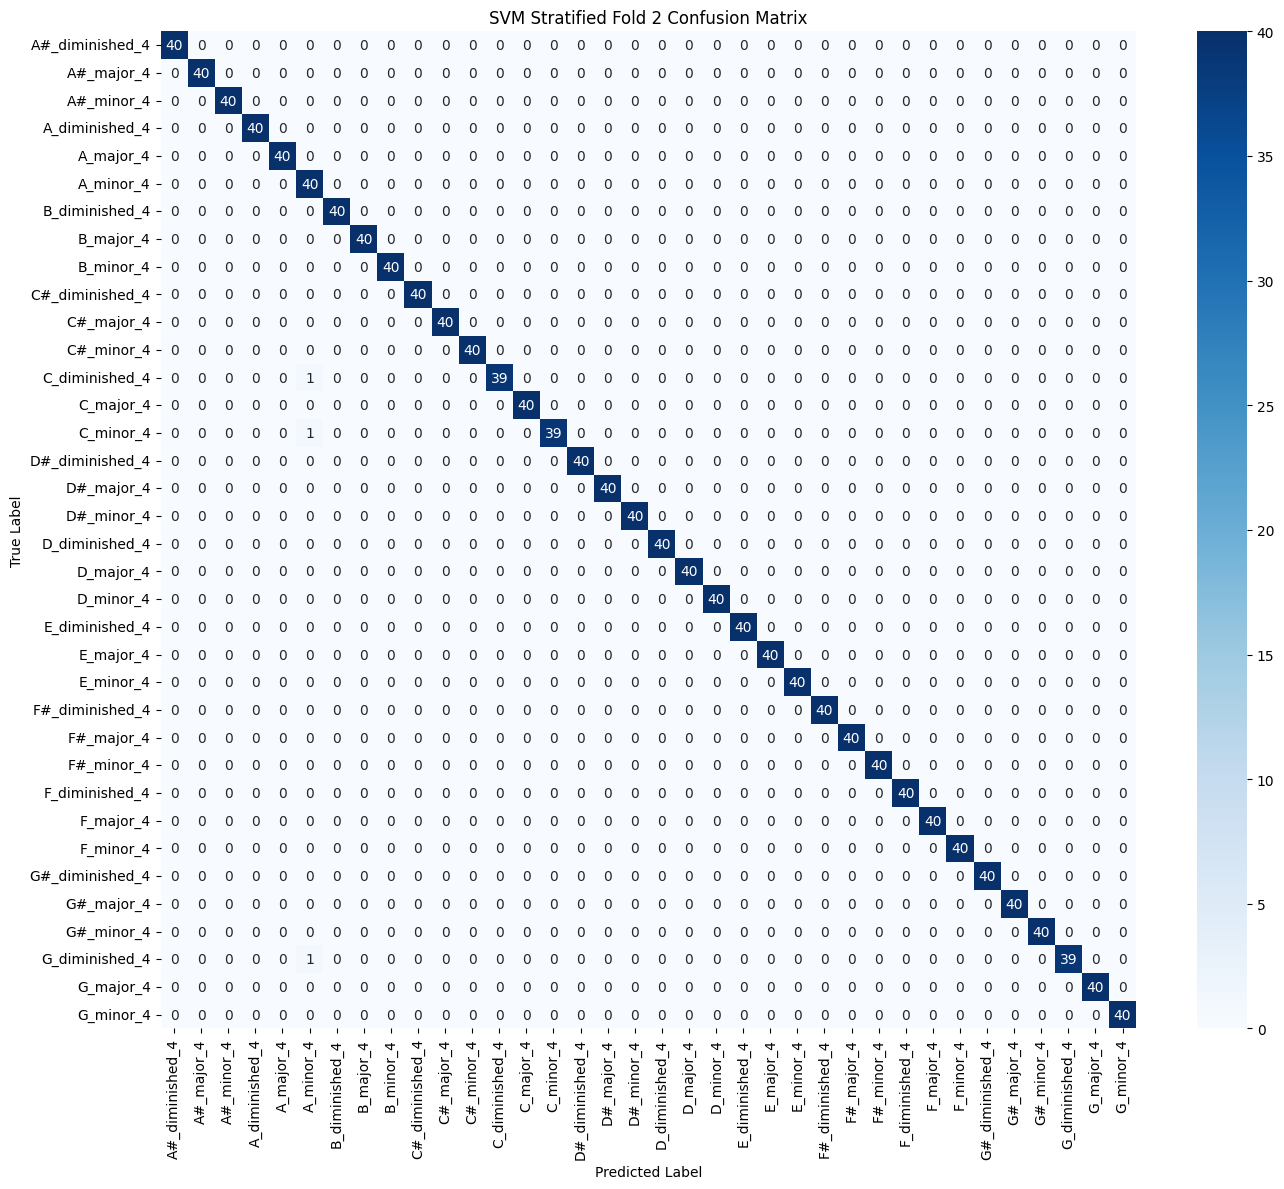

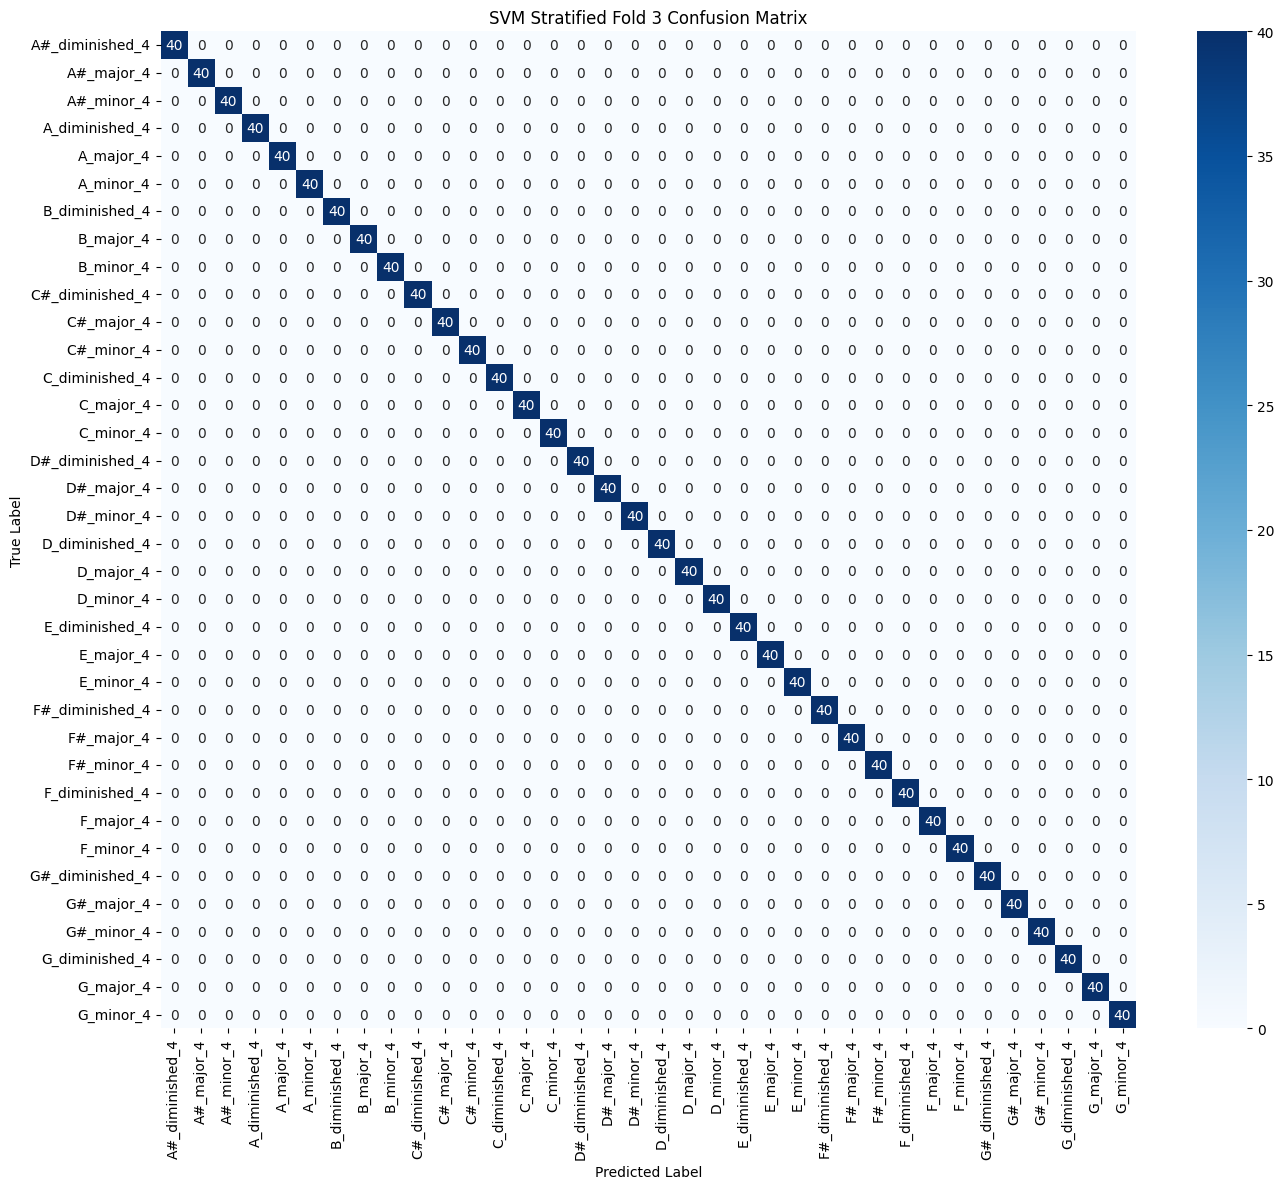

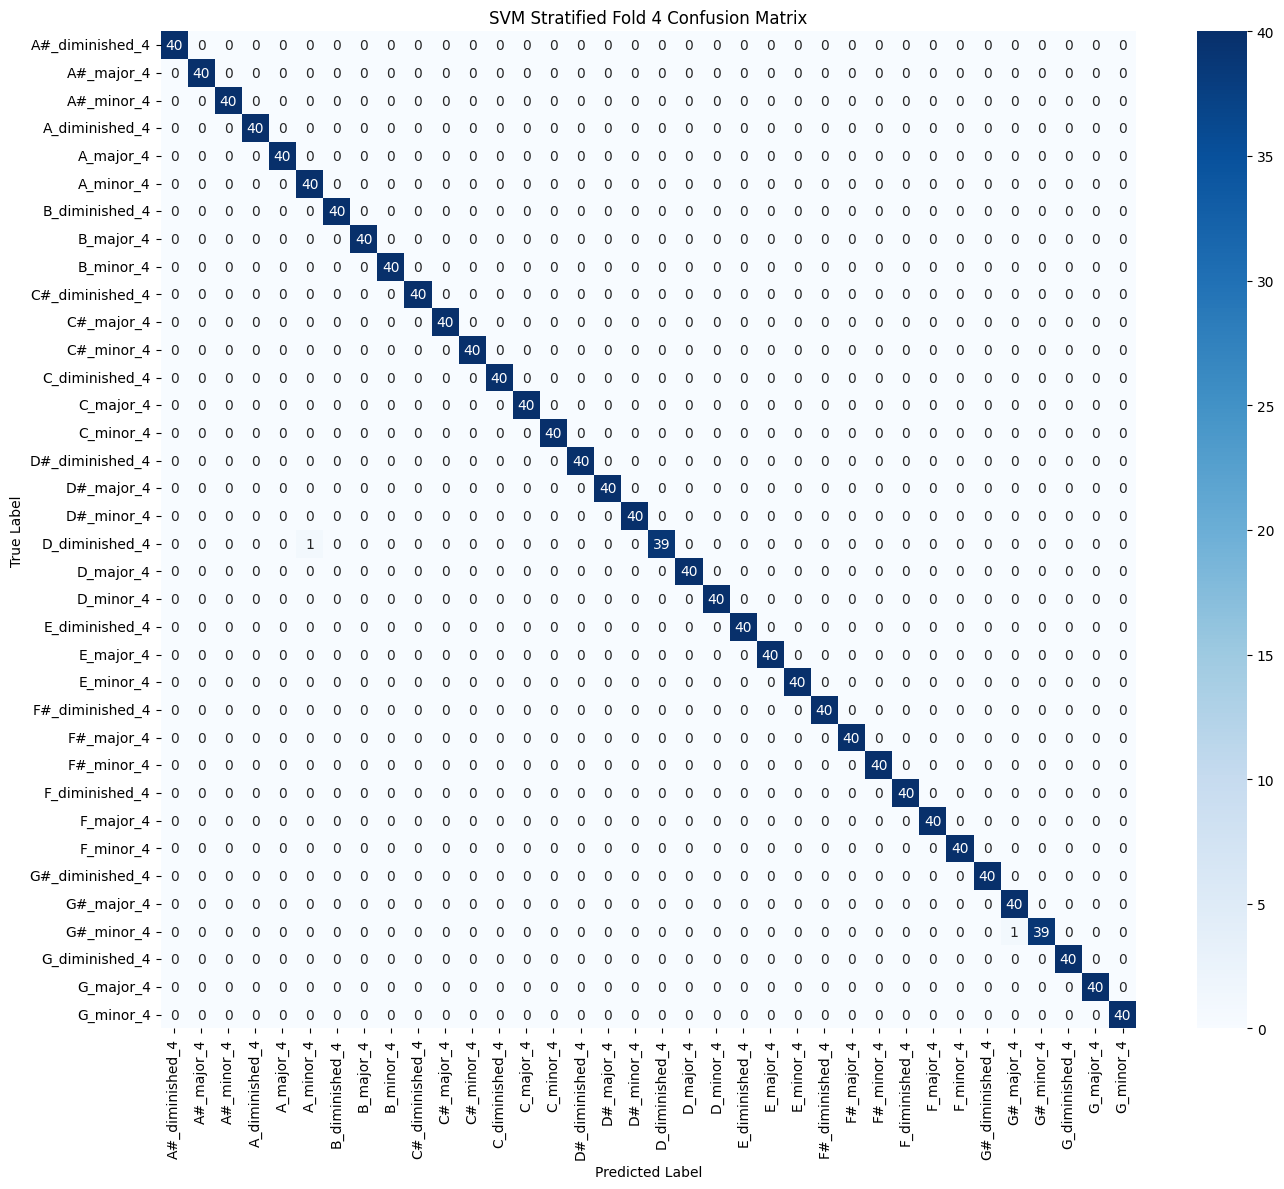

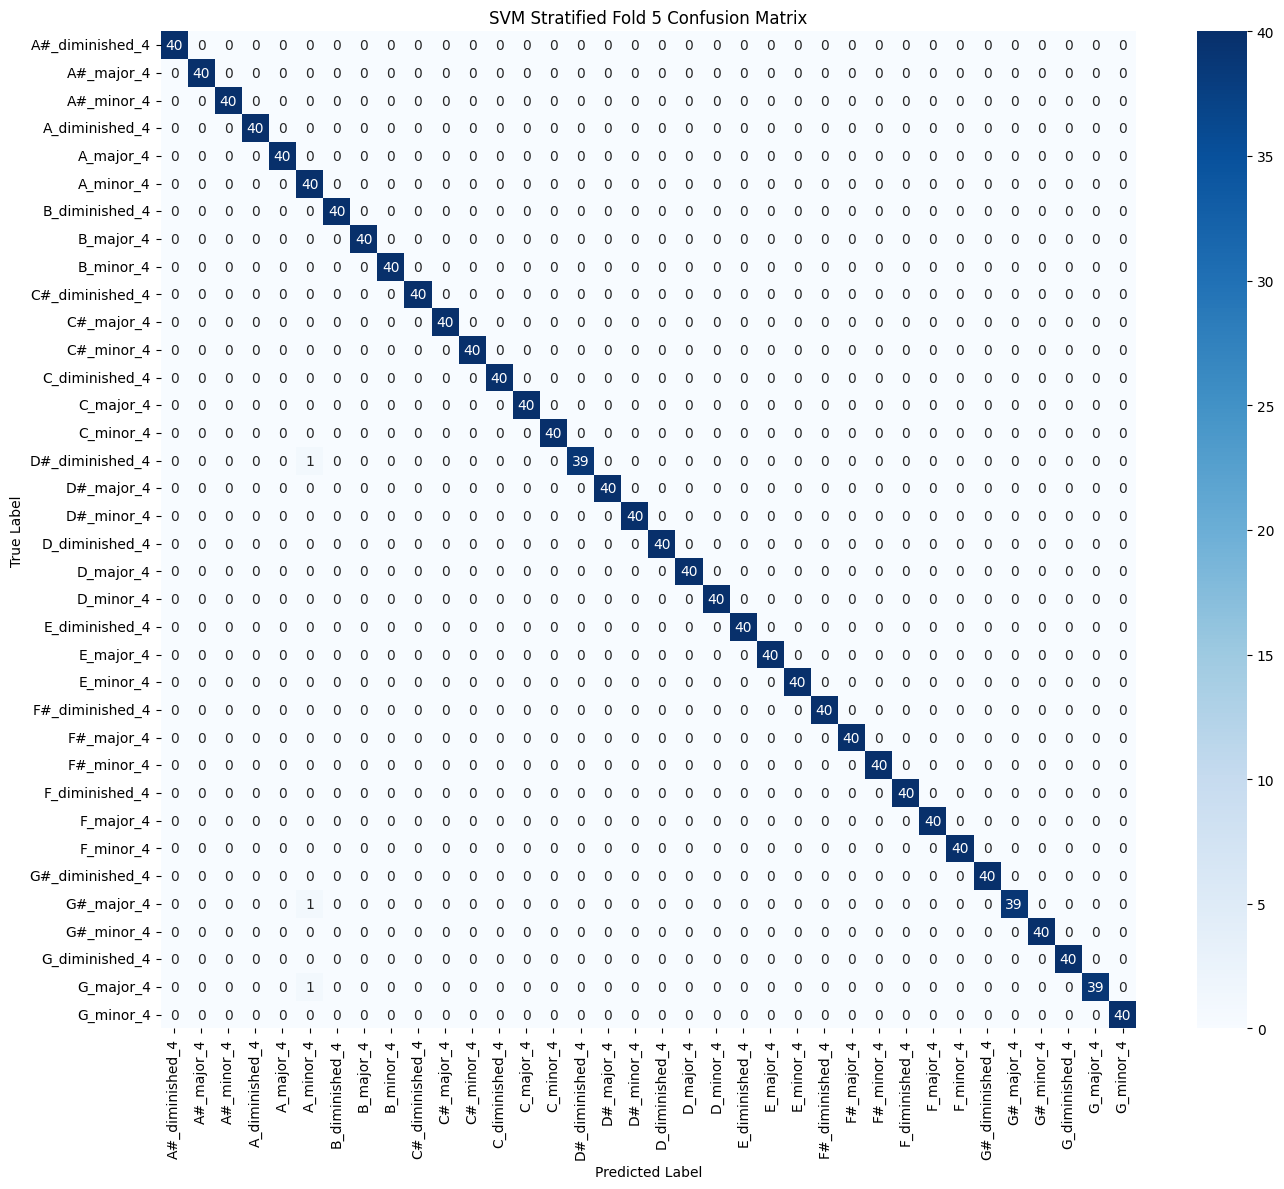

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

svm_class_labels = svm_label_encoder.classes_

for i, cm in enumerate(svm_sfold_confusion_matrices):
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=svm_class_labels,
        yticklabels=svm_class_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'SVM Stratified Fold {i+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()

## Accuracy & Loss Plot

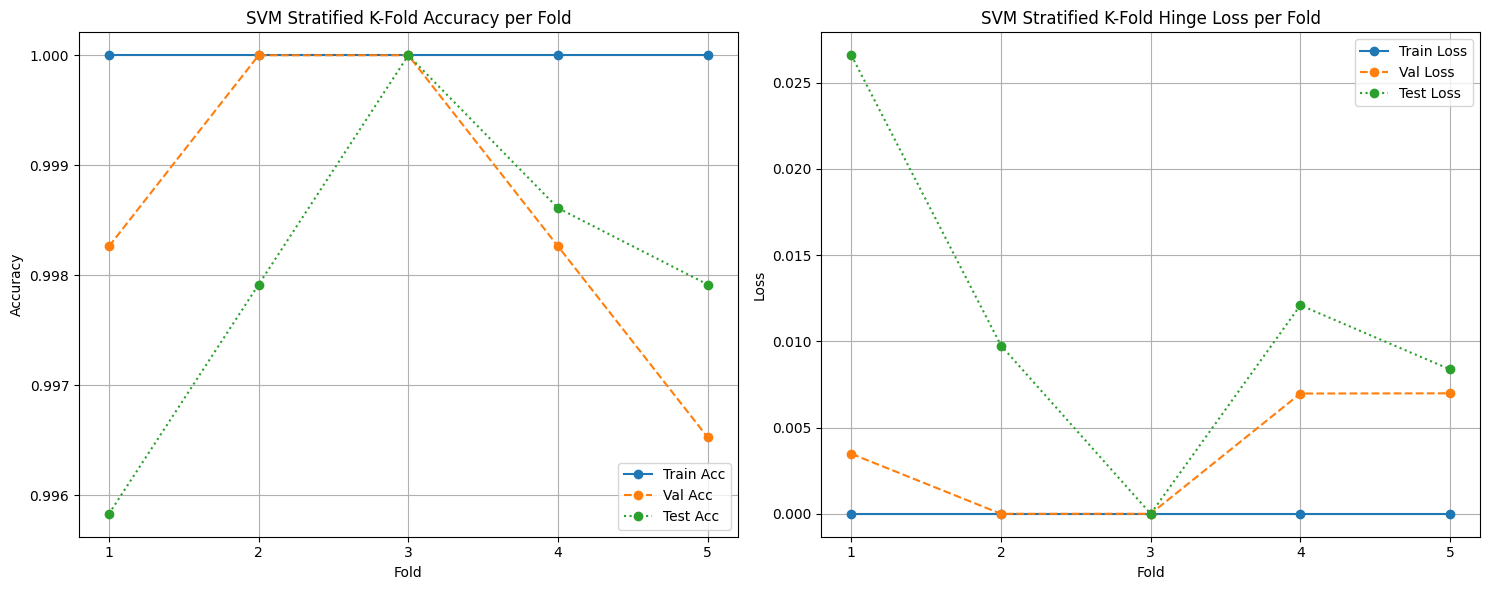

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fold_numbers = np.arange(1, len(svm_sfold_train_accuracies) + 1)

plt.figure(figsize=(15, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(fold_numbers, svm_sfold_train_accuracies, marker='o', label='Train Acc')
plt.plot(fold_numbers, svm_sfold_val_accuracies, marker='o', linestyle='--', label='Val Acc')
plt.plot(fold_numbers, svm_sfold_test_accuracies, marker='o', linestyle=':', label='Test Acc')
plt.title('SVM Stratified K-Fold Accuracy per Fold')
plt.ylabel('Accuracy')
plt.xlabel('Fold')
plt.xticks(fold_numbers)
plt.legend(loc='lower right')
plt.grid(True)

# --- Loss (multiclass hinge loss) ---
plt.subplot(1, 2, 2)
plt.plot(fold_numbers, svm_sfold_train_losses, marker='o', label='Train Loss')
plt.plot(fold_numbers, svm_sfold_val_losses, marker='o', linestyle='--', label='Val Loss')
plt.plot(fold_numbers, svm_sfold_test_losses, marker='o', linestyle=':', label='Test Loss')
plt.title('SVM Stratified K-Fold Hinge Loss per Fold')
plt.ylabel('Loss')
plt.xlabel('Fold')
plt.xticks(fold_numbers)
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

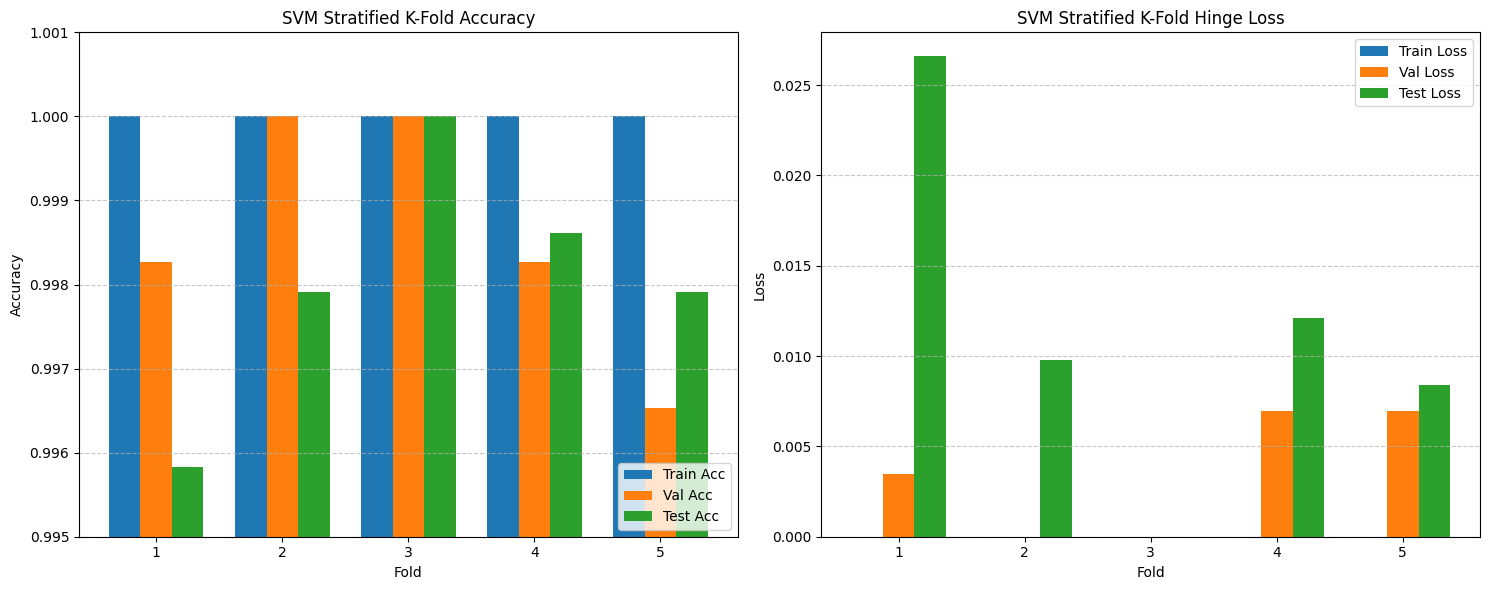

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming your data lists are already defined
fold_numbers = np.arange(1, len(svm_sfold_train_accuracies) + 1)
width = 0.25  # The width of the bars

plt.figure(figsize=(15, 6))

# --- Accuracy Chart ---
plt.subplot(1, 2, 1)
plt.bar(fold_numbers - width, svm_sfold_train_accuracies, width, label='Train Acc', color='#1f77b4')
plt.bar(fold_numbers, svm_sfold_val_accuracies, width, label='Val Acc', color='#ff7f0e')
plt.bar(fold_numbers + width, svm_sfold_test_accuracies, width, label='Test Acc', color='#2ca02c')

plt.title('SVM Stratified K-Fold Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Fold')
plt.xticks(fold_numbers)
plt.ylim(0.995, 1.001) # Zooming in like your original plot
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# --- Loss Chart ---
plt.subplot(1, 2, 2)
plt.bar(fold_numbers - width, svm_sfold_train_losses, width, label='Train Loss', color='#1f77b4')
plt.bar(fold_numbers, svm_sfold_val_losses, width, label='Val Loss', color='#ff7f0e')
plt.bar(fold_numbers + width, svm_sfold_test_losses, width, label='Test Loss', color='#2ca02c')

plt.title('SVM Stratified K-Fold Hinge Loss')
plt.ylabel('Loss')
plt.xlabel('Fold')
plt.xticks(fold_numbers)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Mean & Std Deviation

In [19]:
import numpy as np

print("=" * 89)
print("              SVM Stratified K-Fold Cross-Validation Summary")
print("=" * 89)
print(f"  {'':>6}  {'Train Acc':>10}  {'Val Acc':>10}  {'Test Acc':>10}  {'Train Loss':>11}  {'Val Loss':>10}  {'Test Loss':>10}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")

for i in range(len(svm_sfold_train_accuracies)):
    print(
        f"  Fold {i+1:>1}  "
        f"{svm_sfold_train_accuracies[i]:>10.4f}  "
        f"{svm_sfold_val_accuracies[i]:>10.4f}  "
        f"{svm_sfold_test_accuracies[i]:>10.4f}  "
        f"{svm_sfold_train_losses[i]:>11.4f}  "
        f"{svm_sfold_val_losses[i]:>10.4f}  "
        f"{svm_sfold_test_losses[i]:>10.4f}"
    )

print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
print(
    f"  {'Mean':>6}  "
    f"{np.mean(svm_sfold_train_accuracies):>10.4f}  "
    f"{np.mean(svm_sfold_val_accuracies):>10.4f}  "
    f"{np.mean(svm_sfold_test_accuracies):>10.4f}  "
    f"{np.mean(svm_sfold_train_losses):>11.4f}  "
    f"{np.mean(svm_sfold_val_losses):>10.4f}  "
    f"{np.mean(svm_sfold_test_losses):>10.4f}"
)
print(
    f"  {'Std':>6}  "
    f"{np.std(svm_sfold_train_accuracies):>10.4f}  "
    f"{np.std(svm_sfold_val_accuracies):>10.4f}  "
    f"{np.std(svm_sfold_test_accuracies):>10.4f}  "
    f"{np.std(svm_sfold_train_losses):>11.4f}  "
    f"{np.std(svm_sfold_val_losses):>10.4f}  "
    f"{np.std(svm_sfold_test_losses):>10.4f}"
)
print("=" * 89)

              SVM Stratified K-Fold Cross-Validation Summary
           Train Acc     Val Acc    Test Acc   Train Loss    Val Loss   Test Loss
  ------  ----------  ----------  ----------  -----------  ----------  ----------
  Fold 1      1.0000      0.9983      0.9958       0.0000      0.0035      0.0266
  Fold 2      1.0000      1.0000      0.9979       0.0000      0.0000      0.0098
  Fold 3      1.0000      1.0000      1.0000       0.0000      0.0000      0.0000
  Fold 4      1.0000      0.9983      0.9986       0.0000      0.0070      0.0121
  Fold 5      1.0000      0.9965      0.9979       0.0000      0.0070      0.0084
  ------  ----------  ----------  ----------  -----------  ----------  ----------
    Mean      1.0000      0.9986      0.9981       0.0000      0.0035      0.0114
     Std      0.0000      0.0013      0.0013       0.0000      0.0031      0.0086


# Test SVM model

## Load Model & Noisy Features

In [3]:
import joblib

svm_model = joblib.load(SVM_MODEL_PATH)
svm_scaler = joblib.load(SVM_SCALER_PATH)
svm_label_encoder = joblib.load(SVM_ENCODER_PATH)
noisy_data = np.load(NOISY_FEATURES_PATH)
noisy_features = noisy_data['features']
noisy_labels = noisy_data['labels']

print(f"SVM model loaded from {MODEL_SAVE_PATH}")
print(f"Classes: {svm_label_encoder.classes_}")

SVM model loaded from ../../svm-models/opus
Classes: ['A#_diminished_4' 'A#_major_4' 'A#_minor_4' 'A_diminished_4' 'A_major_4'
 'A_minor_4' 'B_diminished_4' 'B_major_4' 'B_minor_4' 'C#_diminished_4'
 'C#_major_4' 'C#_minor_4' 'C_diminished_4' 'C_major_4' 'C_minor_4'
 'D#_diminished_4' 'D#_major_4' 'D#_minor_4' 'D_diminished_4' 'D_major_4'
 'D_minor_4' 'E_diminished_4' 'E_major_4' 'E_minor_4' 'F#_diminished_4'
 'F#_major_4' 'F#_minor_4' 'F_diminished_4' 'F_major_4' 'F_minor_4'
 'G#_diminished_4' 'G#_major_4' 'G#_minor_4' 'G_diminished_4' 'G_major_4'
 'G_minor_4']


## Test SVM Model

SVM Test Accuracy on Noisy Dataset: 0.5847

Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      0.48      0.65       100
     A#_major_4       0.98      0.98      0.98       100
     A#_minor_4       1.00      0.97      0.98       100
 A_diminished_4       1.00      0.40      0.57       100
      A_major_4       1.00      0.98      0.99       100
      A_minor_4       0.21      1.00      0.35       100
 B_diminished_4       1.00      0.03      0.06       100
      B_major_4       1.00      0.52      0.68       100
      B_minor_4       1.00      0.74      0.85       100
C#_diminished_4       1.00      0.01      0.02       100
     C#_major_4       0.78      0.07      0.13       100
     C#_minor_4       0.60      0.03      0.06       100
 C_diminished_4       0.93      0.67      0.78       100
      C_major_4       0.00      0.00      0.00       100
      C_minor_4       0.00      0.00      0.00       100
D#_diminished_4    

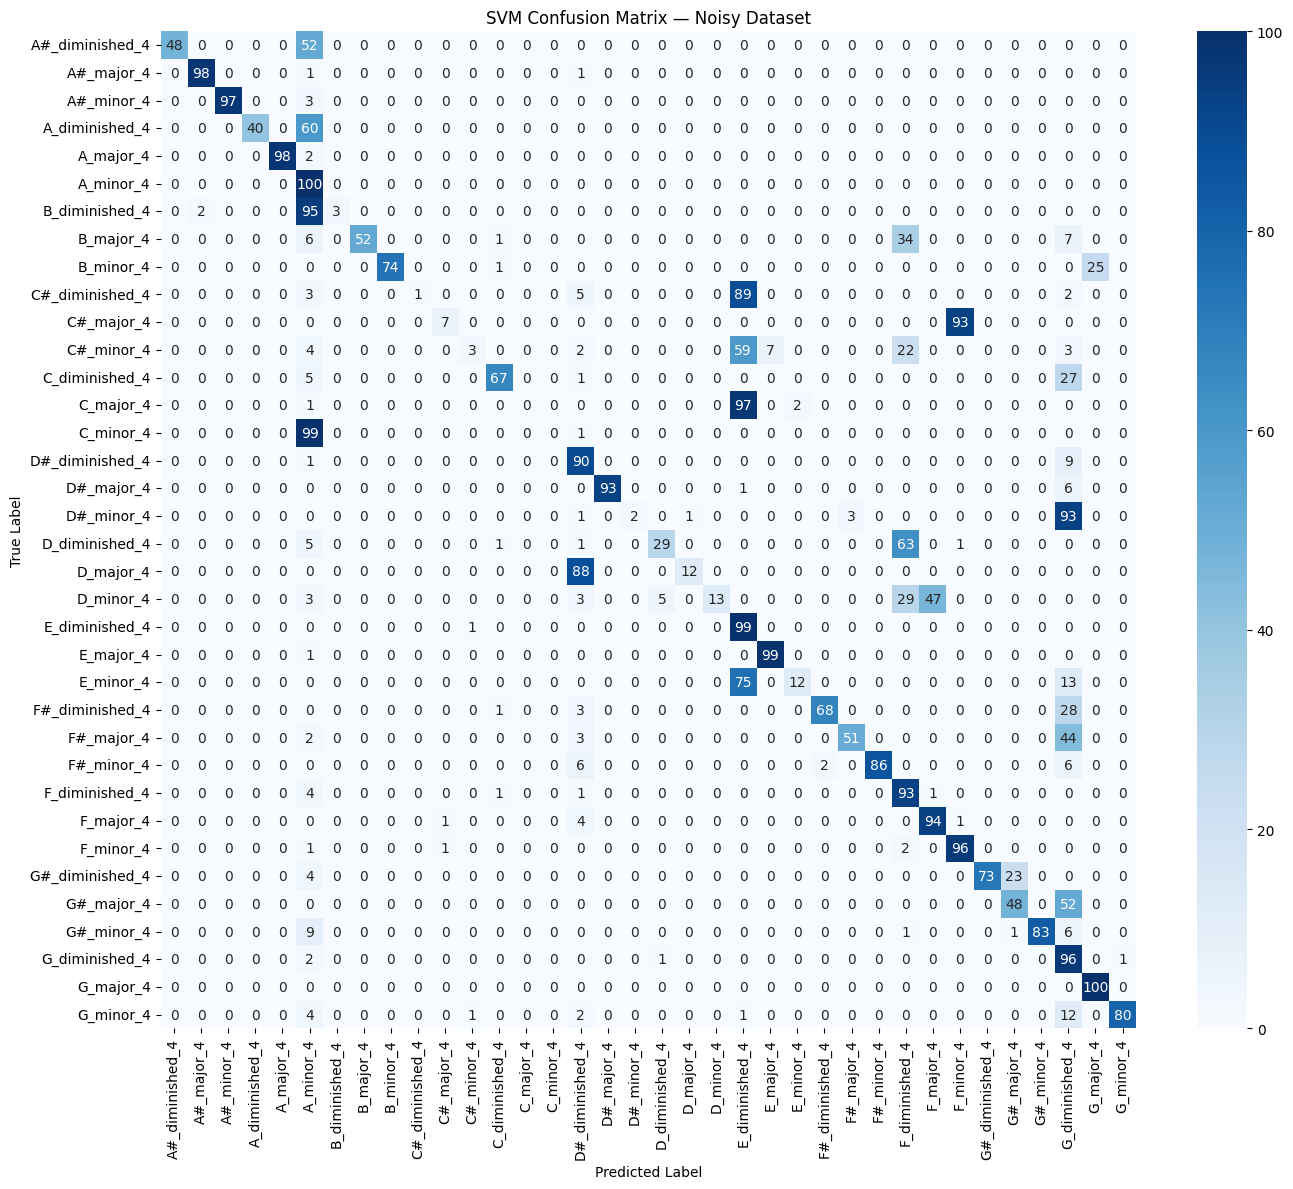

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Flatten and scale noisy features the same way as training data
noisy_features_flat   = noisy_features.reshape(noisy_features.shape[0], -1)
noisy_features_scaled = svm_scaler.fit_transform(noisy_features_flat)

# Encode noisy labels using the loaded label encoder
noisy_svm_encoded = svm_label_encoder.transform(noisy_labels)

# Predict
y_noisy_pred = svm_model.predict(noisy_features_scaled)

# Accuracy & report
noisy_svm_accuracy = accuracy_score(noisy_svm_encoded, y_noisy_pred)
print(f"SVM Test Accuracy on Noisy Dataset: {noisy_svm_accuracy:.4f}")

svm_class_labels = svm_label_encoder.classes_
report_noisy_svm = classification_report(noisy_svm_encoded, y_noisy_pred, target_names=svm_class_labels, zero_division=0)
print("\nClassification Report:\n", report_noisy_svm)

# Confusion matrix
cm_noisy_svm = confusion_matrix(noisy_svm_encoded, y_noisy_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_noisy_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_class_labels, yticklabels=svm_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix — Noisy Dataset')
plt.tight_layout()
plt.show()